In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/UHIMWS/analise_sensores_temperatura.xlsx')

Sensores encontrados: 12
 - temp.aht10
 - temp.aht25
 - temp.bme280
 - temp.bmp180
 - temp.bmp280
 - temp.bmp388
 - temp.dht11
 - temp.dht22
 - temp.ds18b20
 - temp.lm35dz
 - temp.lm75
 - temp.mcp9808

Dataset original: 62308 linhas
Dataset após filtro de data: 25238 linhas
Dataset limpo: 25238 linhas


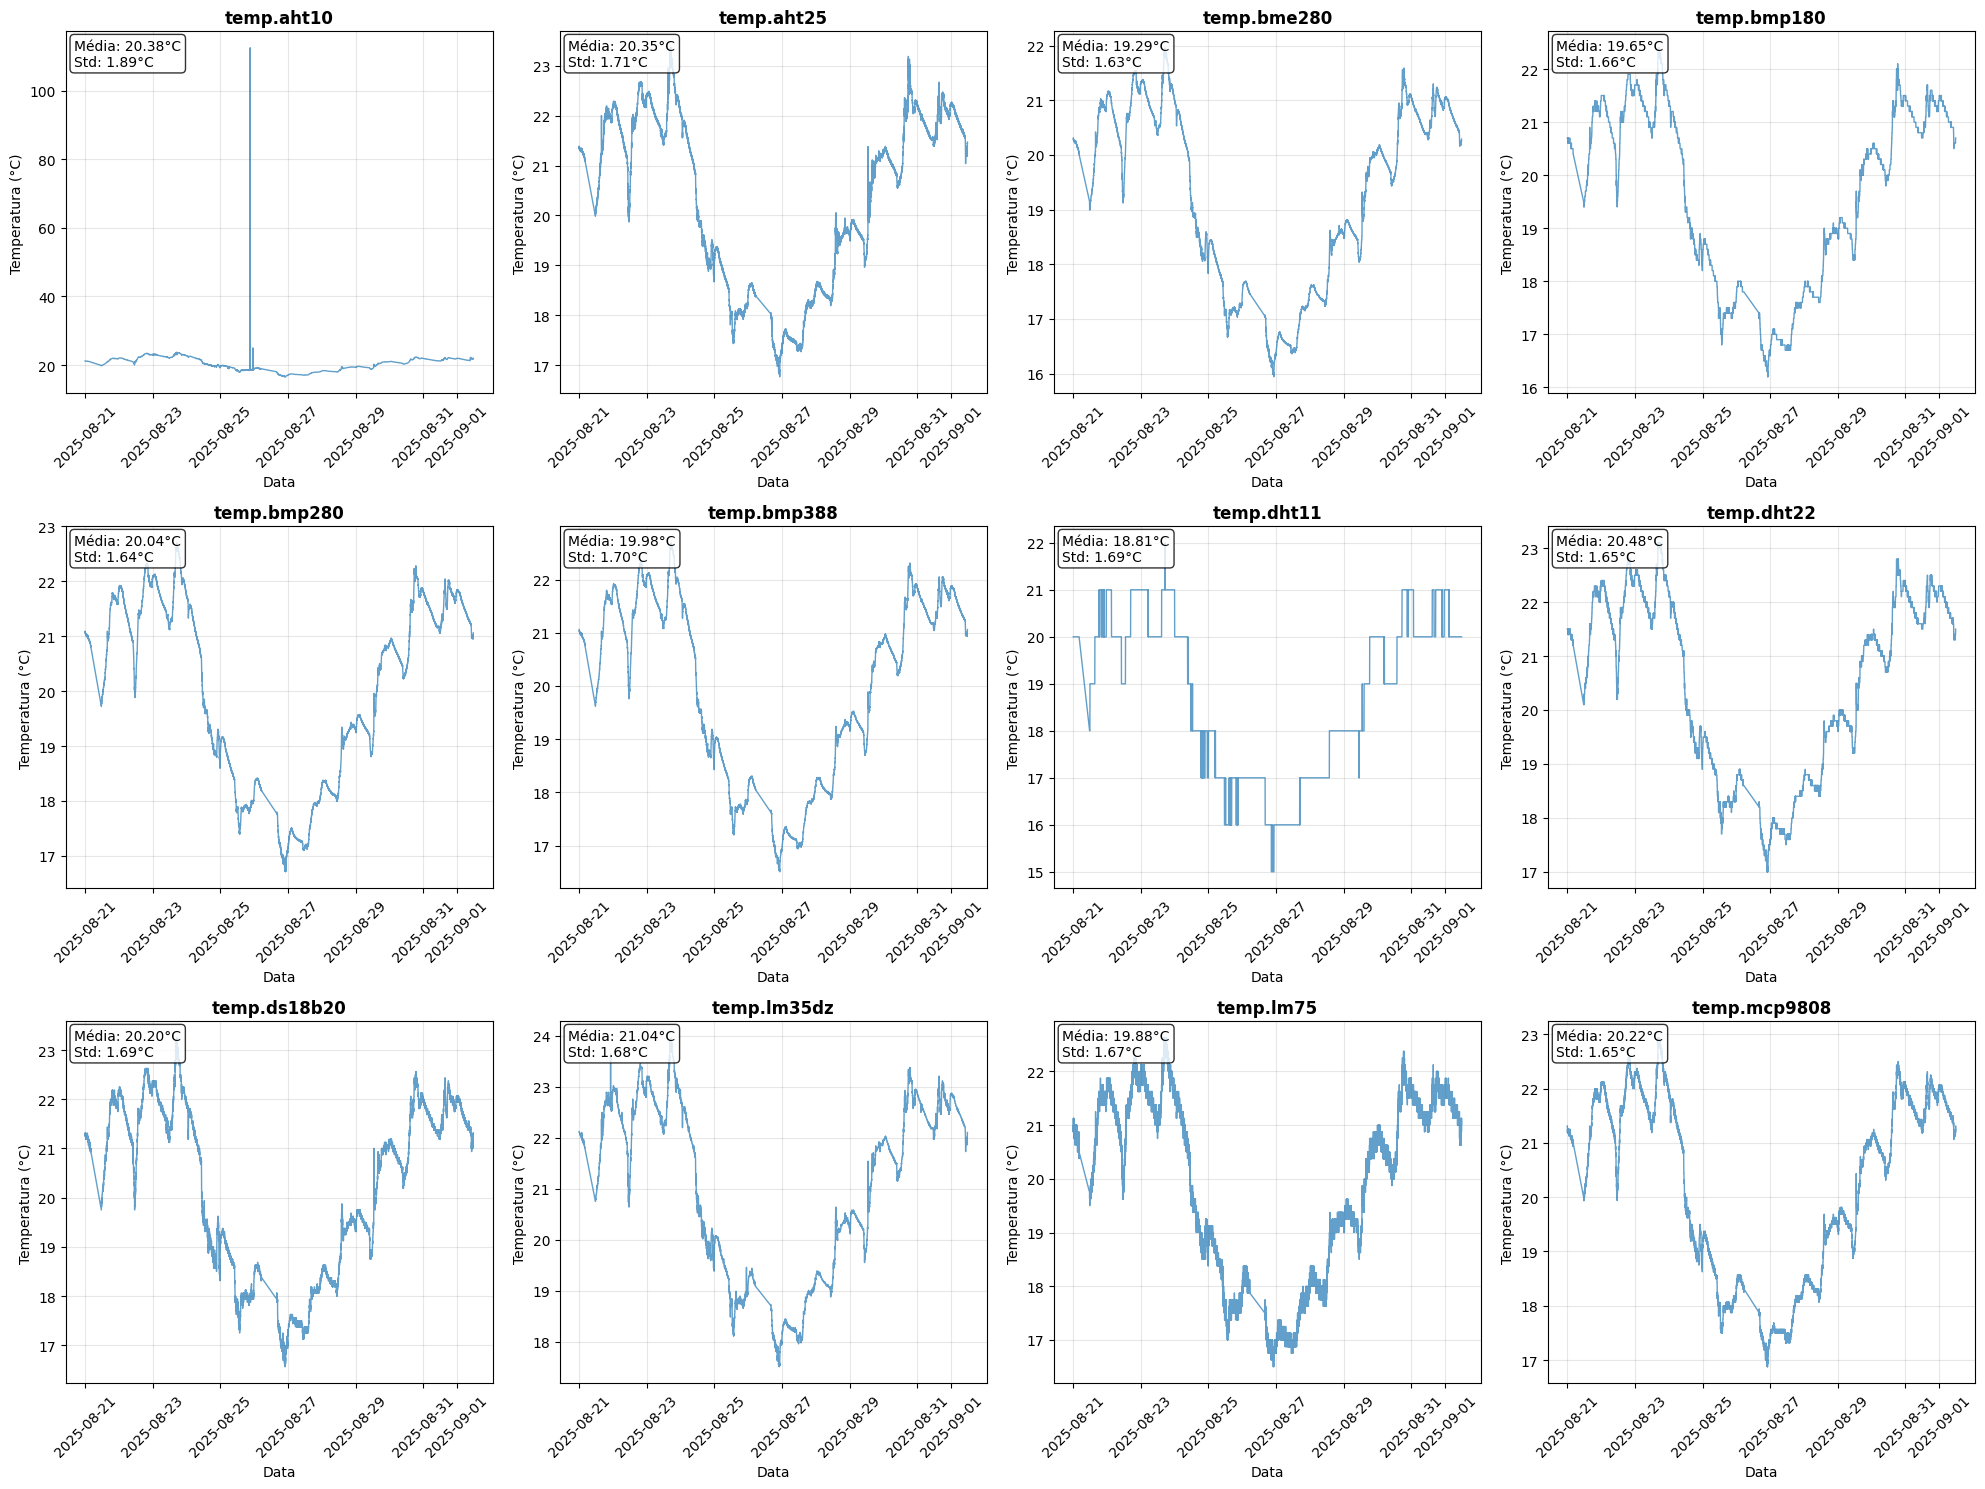


ESTATÍSTICAS DESCRITIVAS - TODOS OS SENSORES
         temp.aht10    temp.aht25   temp.bme280   temp.bmp180   temp.bmp280  \
count  25238.000000  25238.000000  25238.000000  25238.000000  25238.000000   
mean      20.383124     20.346638     19.286879     19.648950     20.043696   
std        1.893604      1.710314      1.626414      1.664333      1.638927   
min       16.575810     16.765400     15.940000     16.200000     16.710480   
25%       19.024328     18.638088     17.700000     18.000000     18.416630   
50%       20.726010     20.930005     19.800000     20.200000     20.571820   
75%       21.875190     21.894402     20.760000     21.200000     21.529700   
max      112.500000     23.359110     21.960000     22.400000     22.702110   

        temp.bmp388    temp.dht11    temp.dht22  temp.ds18b20   temp.lm35dz  \
count  25238.000000  25238.000000  25238.000000  25238.000000  25238.000000   
mean      19.979254     18.812663     20.477538     20.198755     21.035424   
std  

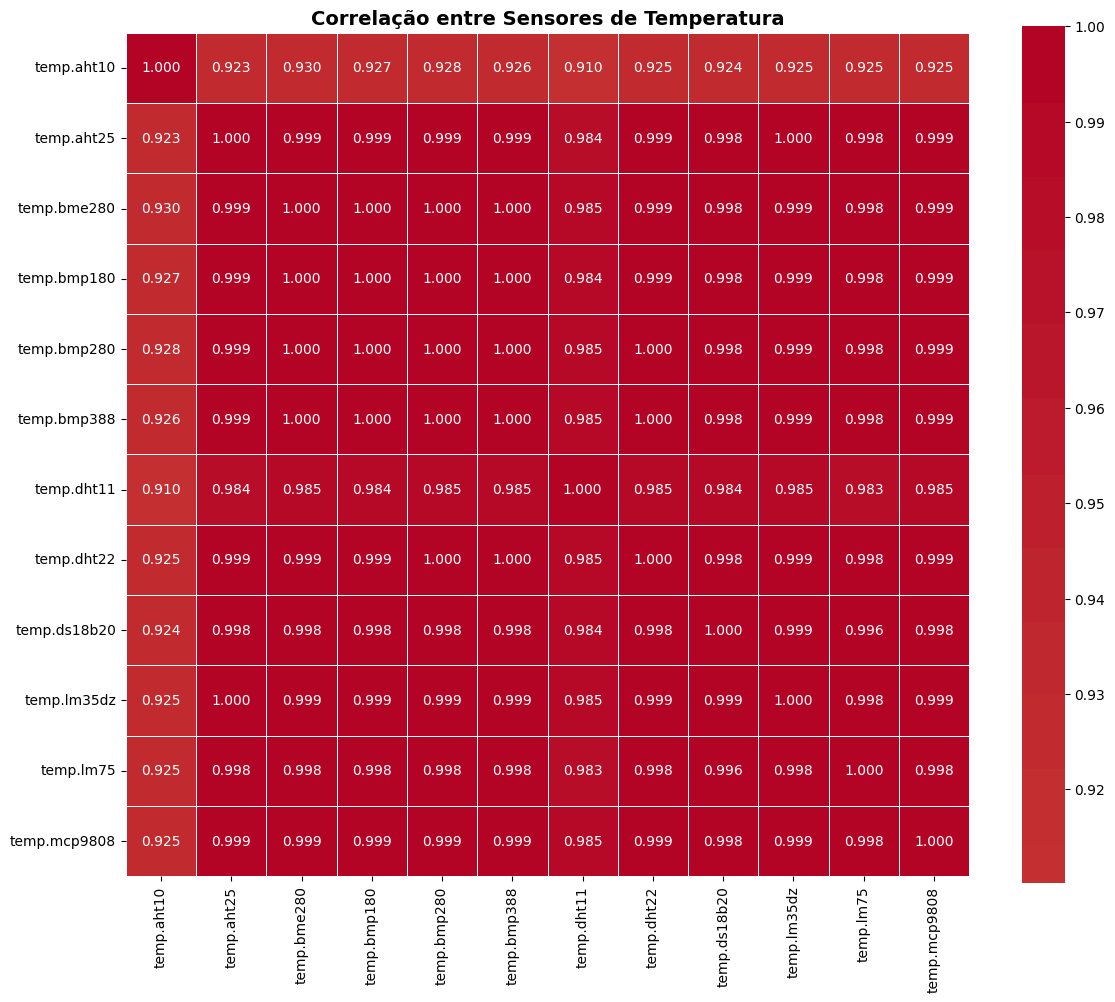

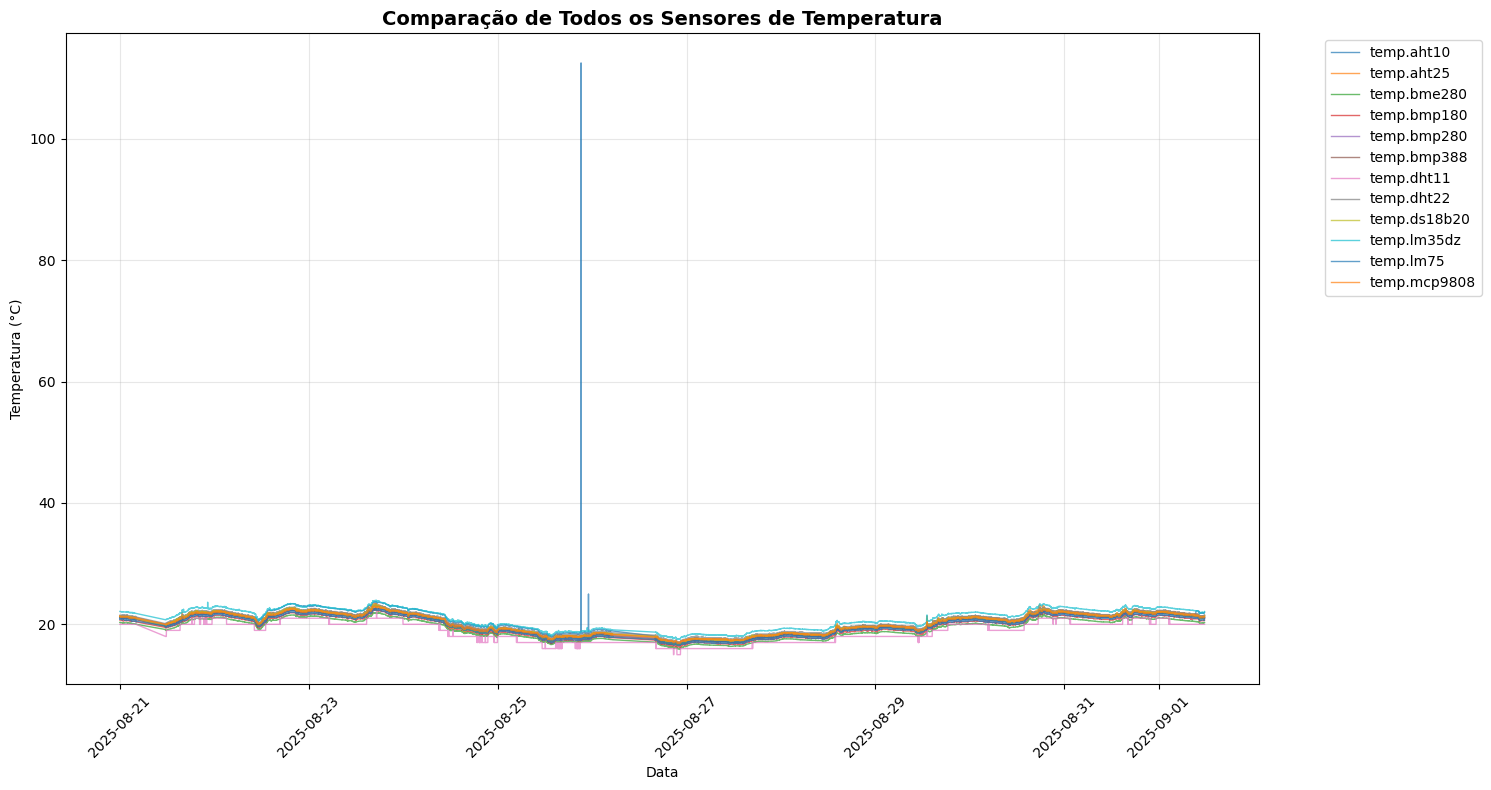

In [ ]:
df['_time'] = pd.to_datetime(df['_time'])

# Definir a data de corte
data_corte = pd.to_datetime('2025-08-21 00:00:00')

# Filtrar os dados a partir da data especificada
df_filtrado = df[df['_time'] >= data_corte].copy()

# Lista completa de sensores de temperatura
sensores = [
    'temp.aht10', 'temp.aht25', 'temp.bme280', 'temp.bmp180',
    'temp.bmp280', 'temp.bmp388', 'temp.dht11', 'temp.dht22',
    'temp.ds18b20', 'temp.lm35dz', 'temp.lm75', 'temp.mcp9808'
]

# Filtrar apenas sensores que existem no DataFrame
sensores_presentes = [sensor for sensor in sensores if sensor in df_filtrado.columns]

print(f"Sensores encontrados: {len(sensores_presentes)}")
for sensor in sensores_presentes:
    print(f" - {sensor}")

# Remover linhas com NaN nos sensores
df_limpo = df_filtrado.dropna(subset=sensores_presentes)

print(f"\nDataset original: {len(df)} linhas")
print(f"Dataset após filtro de data: {len(df_filtrado)} linhas")
print(f"Dataset limpo: {len(df_limpo)} linhas")

# Calcular número de linhas e colunas para subplots
n_sensores = len(sensores_presentes)
n_cols = 4  # 4 colunas
n_rows = (n_sensores + n_cols - 1) // n_cols  # Arredondar para cima

# Criar figura com subplots para todos os sensores
plt.figure(figsize=(20, 5 * n_rows))

for i, sensor in enumerate(sensores_presentes, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.plot(df_limpo['_time'], df_limpo[sensor], label=sensor, alpha=0.7, linewidth=1)
    plt.title(sensor, fontsize=12, fontweight='bold')
    plt.xlabel('Data')
    plt.ylabel('Temperatura (°C)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # Adicionar estatísticas no gráfico
    media = df_limpo[sensor].mean()
    std = df_limpo[sensor].std()
    plt.text(0.02, 0.98, f'Média: {media:.2f}°C\nStd: {std:.2f}°C',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("\n" + "="*50)
print("ESTATÍSTICAS DESCRITIVAS - TODOS OS SENSORES")
print("="*50)
print(df_limpo[sensores_presentes].describe())

# Correlação entre sensores
print("\n" + "="*50)
print("MATRIZ DE CORRELAÇÃO ENTRE SENSORES")
print("="*50)
correlacao = df_limpo[sensores_presentes].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Correlação entre Sensores de Temperatura', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico comparativo - todos os sensores juntos
plt.figure(figsize=(15, 8))
for sensor in sensores_presentes:
    plt.plot(df_limpo['_time'], df_limpo[sensor], label=sensor, alpha=0.7, linewidth=1)

plt.title('Comparação de Todos os Sensores de Temperatura', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("INVESTIGAÇÃO RÁPIDA - VALOR MÁXIMO DO temp.aht10")
print("="*50)

max_temp = df_limpo['temp.aht10'].max()
data_max_temp = df_limpo[df_limpo['temp.aht10'] == max_temp]['_time'].iloc[0]

print(f"Temperatura máxima: {max_temp}°C")
print(f"Data/hora: {data_max_temp}")
print(f"Dia da semana: {data_max_temp.strftime('%A')}")

# Verificar se é um outlier isolado ou se há outros valores altos
outliers = df_limpo[df_limpo['temp.aht10'] > 40]
print(f"\nRegistros acima de 40°C: {len(outliers)}")
if len(outliers) > 0:
    print("Datas dos outliers:")
    for idx, row in outliers[['_time', 'temp.aht10']].iterrows():
        print(f"  {row['_time']} - {row['temp.aht10']:.2f}°C")

INVESTIGAÇÃO RÁPIDA - VALOR MÁXIMO DO temp.aht10
Temperatura máxima: 112.5°C
Data/hora: 2025-08-25 21:11:41
Dia da semana: Monday

Registros acima de 40°C: 1
Datas dos outliers:
  2025-08-25 21:11:41 - 112.50°C


In [ ]:
# Função para analisar os sensores em uma janela de tempo específica
def analisar_janela_temporal(data_inicio, data_fim, df):
    print(f"\n{'='*60}")
    print(f"ANÁLISE: {data_inicio} até {data_fim}")
    print(f"{'='*60}")

    # Converter para datetime
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)

    # Filtrar dados na janela temporal
    df_janela = df[(df['_time'] >= inicio) & (df['_time'] <= fim)]

    print(f"Total de registros na janela: {len(df_janela)}")

    if len(df_janela) == 0:
        print("Nenhum registro encontrado nesta janela temporal.")
        return

    # Analisar cada sensor
    for sensor in sensores_presentes:
        if sensor in df_janela.columns:
            dados_sensor = df_janela[sensor].dropna()
            if len(dados_sensor) > 0:
                print(f"\n📊 {sensor}:")
                print(f"   Média: {dados_sensor.mean():.3f}°C")
                print(f"   Mínima: {dados_sensor.min():.3f}°C")
                print(f"   Máxima: {dados_sensor.max():.3f}°C")
                print(f"   Desvio Padrão: {dados_sensor.std():.3f}°C")
                print(f"   Nº de leituras: {len(dados_sensor)}")
            else:
                print(f"\n❌ {sensor}: Sem dados válidos")

# Primeira janela: 00:00:00 até 00:02:26
analisar_janela_temporal('2025-08-21 00:00:00', '2025-08-21 00:02:26', df_limpo)

# Segunda janela: 00:00:00 até 00:03:40
analisar_janela_temporal('2025-08-21 00:00:00', '2025-08-21 00:03:40', df_limpo)

# Terceira janela: 00:00:00 até 00:05:29
analisar_janela_temporal('2025-08-21 00:00:00', '2025-08-21 00:05:29', df_limpo)


ANÁLISE: 2025-08-21 00:00:00 até 2025-08-21 00:02:26
Total de registros na janela: 5

📊 temp.aht10:
   Média: 21.191°C
   Mínima: 21.185°C
   Máxima: 21.197°C
   Desvio Padrão: 0.006°C
   Nº de leituras: 5

📊 temp.aht25:
   Média: 21.369°C
   Mínima: 21.350°C
   Máxima: 21.381°C
   Desvio Padrão: 0.012°C
   Nº de leituras: 5

📊 temp.bme280:
   Média: 20.302°C
   Mínima: 20.300°C
   Máxima: 20.310°C
   Desvio Padrão: 0.004°C
   Nº de leituras: 5

📊 temp.bmp180:
   Média: 20.700°C
   Mínima: 20.700°C
   Máxima: 20.700°C
   Desvio Padrão: 0.000°C
   Nº de leituras: 5

📊 temp.bmp280:
   Média: 21.087°C
   Mínima: 21.086°C
   Máxima: 21.091°C
   Desvio Padrão: 0.002°C
   Nº de leituras: 5

📊 temp.bmp388:
   Média: 21.048°C
   Mínima: 21.040°C
   Máxima: 21.060°C
   Desvio Padrão: 0.008°C
   Nº de leituras: 5

📊 temp.dht11:
   Média: 20.000°C
   Mínima: 20.000°C
   Máxima: 20.000°C
   Desvio Padrão: 0.000°C
   Nº de leituras: 5

📊 temp.dht22:
   Média: 21.500°C
   Mínima: 21.500°C
   Máxima

In [ ]:
# Função para criar tabela resumo comparativa
def criar_tabela_resumo(janelas, df):
    resultados = []

    for i, (inicio, fim) in enumerate(janelas, 1):
        inicio_dt = pd.to_datetime(inicio)
        fim_dt = pd.to_datetime(fim)

        df_janela = df[(df['_time'] >= inicio_dt) & (df['_time'] <= fim_dt)]

        for sensor in sensores_presentes:
            if sensor in df_janela.columns:
                dados = df_janela[sensor].dropna()
                if len(dados) > 0:
                    resultados.append({
                        'Janela': f'Janela {i}',
                        'Período': f"{inicio.split()[1]} - {fim.split()[1]}",
                        'Sensor': sensor,
                        'Média': dados.mean(),
                        'Mínima': dados.min(),
                        'Máxima': dados.max(),
                        'Desvio_Padrão': dados.std(),
                        'Leituras': len(dados)
                    })

    return pd.DataFrame(resultados)

# Definir as janelas
janelas = [
    ('2025-08-21 00:00:00', '2025-08-21 00:02:26'),
    ('2025-08-21 00:00:00', '2025-08-21 00:03:40'),
    ('2025-08-21 00:00:00', '2025-08-21 00:05:29')
]

# Criar tabela resumo
df_resumo = criar_tabela_resumo(janelas, df_limpo)

print("TABELA RESUMO COMPARATIVA")
print("="*80)
print(df_resumo.to_string(index=False, float_format='%.3f'))

# Salvar em CSV se desejar
# df_resumo.to_csv('analise_janelas_temperatura.csv', index=False)

TABELA RESUMO COMPARATIVA
  Janela             Período       Sensor  Média  Mínima  Máxima  Desvio_Padrão  Leituras
Janela 1 00:00:00 - 00:02:26   temp.aht10 21.191  21.185  21.197          0.006         5
Janela 1 00:00:00 - 00:02:26   temp.aht25 21.369  21.350  21.381          0.012         5
Janela 1 00:00:00 - 00:02:26  temp.bme280 20.302  20.300  20.310          0.004         5
Janela 1 00:00:00 - 00:02:26  temp.bmp180 20.700  20.700  20.700          0.000         5
Janela 1 00:00:00 - 00:02:26  temp.bmp280 21.087  21.086  21.091          0.002         5
Janela 1 00:00:00 - 00:02:26  temp.bmp388 21.048  21.040  21.060          0.008         5
Janela 1 00:00:00 - 00:02:26   temp.dht11 20.000  20.000  20.000          0.000         5
Janela 1 00:00:00 - 00:02:26   temp.dht22 21.500  21.500  21.500          0.000         5
Janela 1 00:00:00 - 00:02:26 temp.ds18b20 21.300  21.250  21.312          0.028         5
Janela 1 00:00:00 - 00:02:26  temp.lm35dz 22.125  22.125  22.125          

In [ ]:
# Análise rápida das três janelas
janelas = [
    ('00:00:00 - 00:02:26', '2025-08-21 00:00:00', '2025-08-21 00:02:26'),
    ('00:00:00 - 00:03:40', '2025-08-21 00:00:00', '2025-08-21 00:03:40'),
    ('00:00:00 - 00:05:29', '2025-08-21 00:00:00', '2025-08-21 00:05:29')
]

for nome, inicio, fim in janelas:
    print(f"\n🎯 JANELA: {nome}")
    print("-" * 50)

    df_temp = df_limpo[
        (df_limpo['_time'] >= pd.to_datetime(inicio)) &
        (df_limpo['_time'] <= pd.to_datetime(fim))
    ]

    for sensor in sensores_presentes:
        if sensor in df_temp.columns:
            dados = df_temp[sensor].dropna()
            if len(dados) > 0:
                print(f"{sensor:15} | Média: {dados.mean():6.2f}°C | "
                      f"Min: {dados.min():5.2f}°C | Max: {dados.max():5.2f}°C | "
                      f"Std: {dados.std():5.2f}°C | N: {len(dados):2d}")


🎯 JANELA: 00:00:00 - 00:02:26
--------------------------------------------------
temp.aht10      | Média:  21.19°C | Min: 21.18°C | Max: 21.20°C | Std:  0.01°C | N:  5
temp.aht25      | Média:  21.37°C | Min: 21.35°C | Max: 21.38°C | Std:  0.01°C | N:  5
temp.bme280     | Média:  20.30°C | Min: 20.30°C | Max: 20.31°C | Std:  0.00°C | N:  5
temp.bmp180     | Média:  20.70°C | Min: 20.70°C | Max: 20.70°C | Std:  0.00°C | N:  5
temp.bmp280     | Média:  21.09°C | Min: 21.09°C | Max: 21.09°C | Std:  0.00°C | N:  5
temp.bmp388     | Média:  21.05°C | Min: 21.04°C | Max: 21.06°C | Std:  0.01°C | N:  5
temp.dht11      | Média:  20.00°C | Min: 20.00°C | Max: 20.00°C | Std:  0.00°C | N:  5
temp.dht22      | Média:  21.50°C | Min: 21.50°C | Max: 21.50°C | Std:  0.00°C | N:  5
temp.ds18b20    | Média:  21.30°C | Min: 21.25°C | Max: 21.31°C | Std:  0.03°C | N:  5
temp.lm35dz     | Média:  22.12°C | Min: 22.12°C | Max: 22.12°C | Std:  0.00°C | N:  5
temp.lm75       | Média:  20.93°C | Min: 20.88°C